In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
data=pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA

In [3]:
data.shape

(1338, 7)

In [4]:
data.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

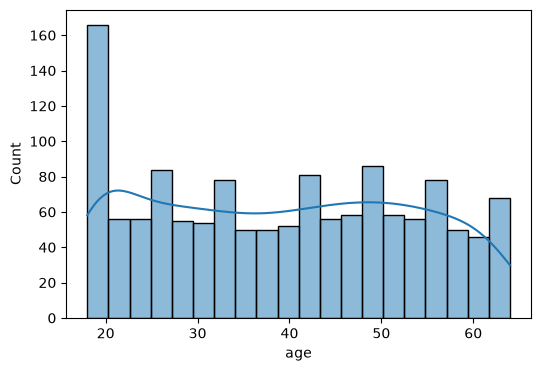

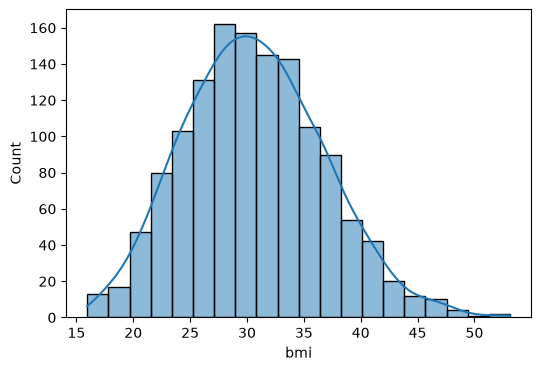

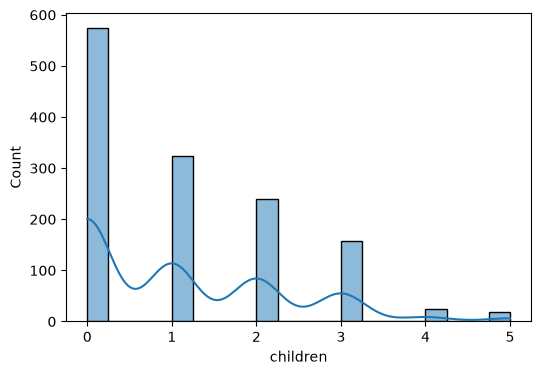

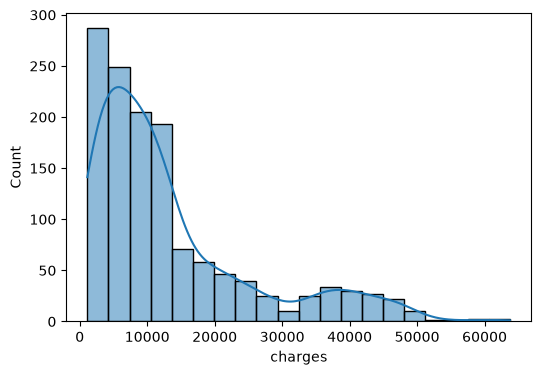

In [9]:
numeric_columns=['age', 'bmi', 'children', 'charges']
for cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[cols],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

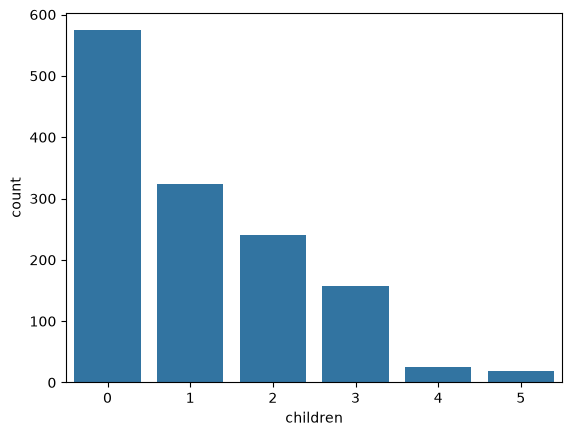

In [10]:
sns.countplot(x=data['children'])

<Axes: xlabel='sex', ylabel='count'>

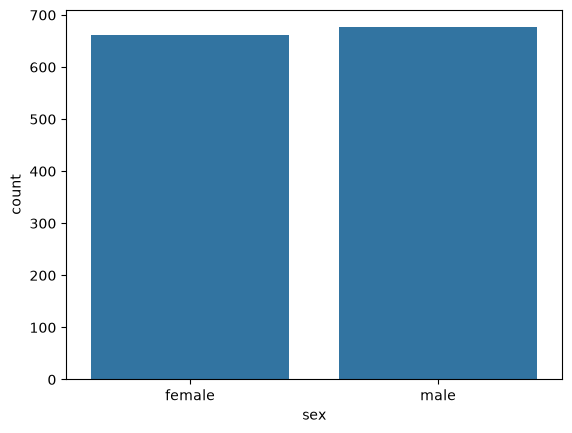

In [11]:
sns.countplot(x=data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

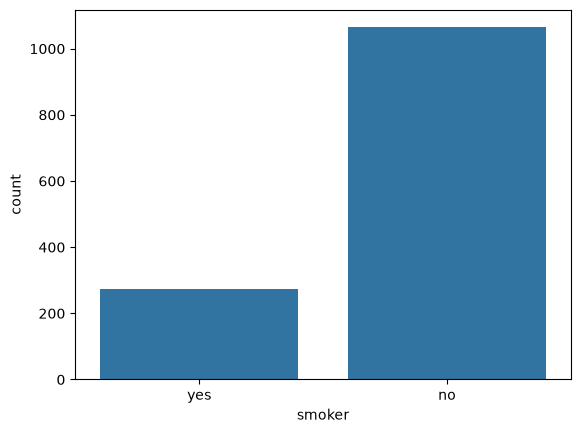

In [12]:
sns.countplot(x=data['smoker'])

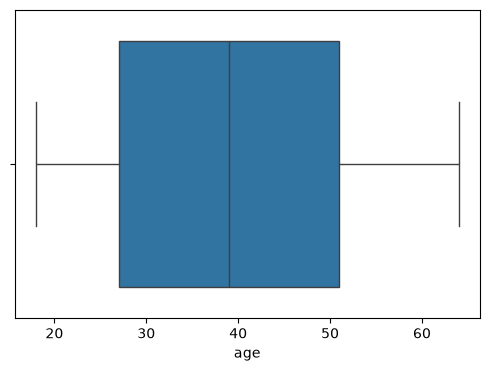

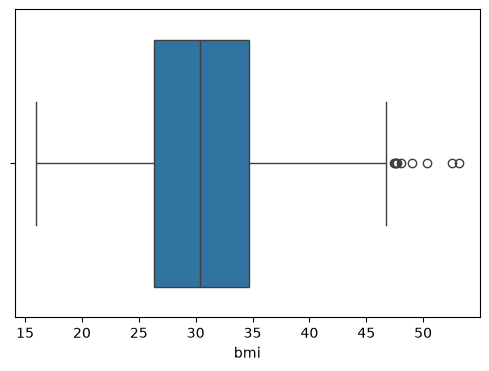

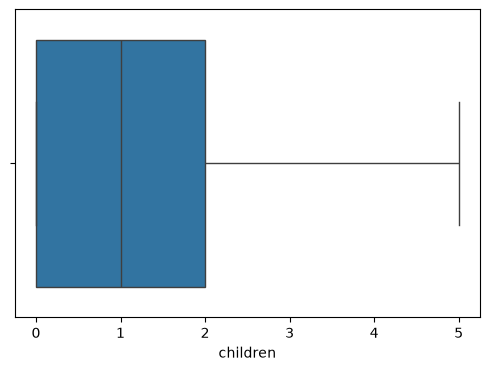

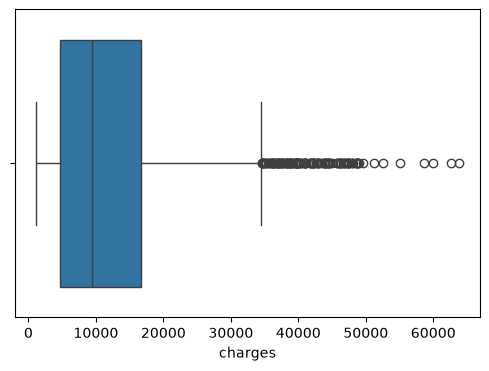

In [13]:
for cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[cols])

<Axes: >

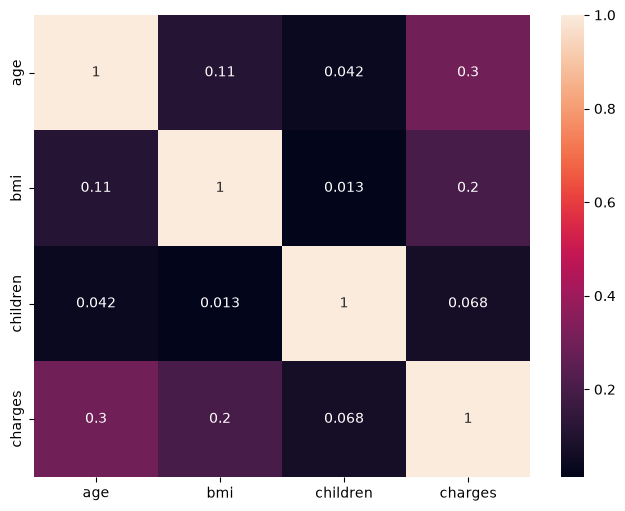

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True)

# Data cleaning and Processing

In [15]:
df=data.copy()
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [16]:
df.shape

(1338, 7)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(1337, 7)

In [19]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [21]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [22]:
df['sex']=df['sex'].map({"male":0,"female":1})

In [23]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [24]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [25]:
df['smoker']=df['smoker'].map({"yes":1,"no":1})

In [26]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


In [27]:
df.rename(columns={'sex':'isFemale','smoker':'isSmoker'},inplace=True)
df

,age,isFemale,bmi,children,isSmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [28]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [29]:
df=pd.get_dummies(df,columns=['region'],drop_first=True)

In [30]:
df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False


In [31]:
df.astype(int)

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,1,1725,0,1,0
2,28,0,33,3,1,4449,0,1,0
3,33,0,22,0,1,21984,1,0,0
4,32,0,28,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0
1334,18,1,31,0,1,2205,0,0,0
1335,18,1,36,0,1,1629,0,1,0
1336,21,1,25,0,1,2007,0,0,1


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

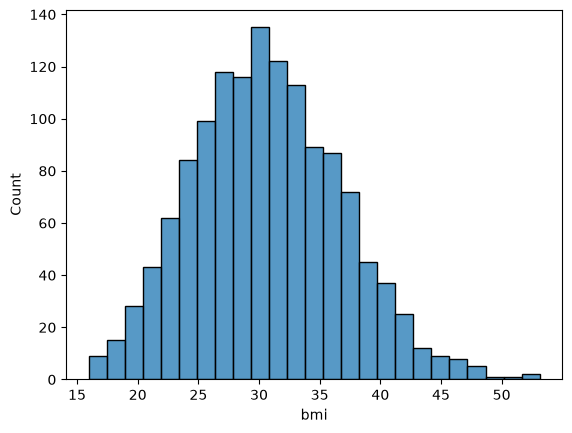

In [32]:
sns.histplot(df['bmi'])

In [42]:
df['bmi_category']=pd.cut(
    df['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['UnderWeight','Normal','OverWeight','Obese']
)

In [43]:
df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,OverWeight
1,18,0,33.770,1,1,1725.55230,False,True,False,Obese
2,28,0,33.000,3,1,4449.46200,False,True,False,Obese
3,33,0,22.705,0,1,21984.47061,True,False,False,Normal
4,32,0,28.880,0,1,3866.85520,True,False,False,OverWeight


In [45]:
df=pd.get_dummies(df,columns=['bmi_category'],drop_first=True)


In [46]:
df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,1,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,1,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,1,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False,False,True,False


In [47]:
df.astype(int)

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,1,1725,0,1,0,0,0,1
2,28,0,33,3,1,4449,0,1,0,0,0,1
3,33,0,22,0,1,21984,1,0,0,1,0,0
4,32,0,28,0,1,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0,0,0,1
1334,18,1,31,0,1,2205,0,0,0,0,0,1
1335,18,1,36,0,1,1629,0,1,0,0,0,1
1336,21,1,25,0,1,2007,0,0,1,0,1,0


In [ ]:
df.columns

In [48]:
df=df.astype(int)

In [49]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df[cols]=scaler.fit_transform(df[cols])

In [50]:
df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,1,0,0,0,1,0


# Day 6 – Insurance Cost Prediction using Linear Regression

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,1,0,0,0,1,0


In [53]:
df.shape

(1337, 12)

In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      1337 non-null   float64
 1   isFemale                 1337 non-null   int64  
 2   bmi                      1337 non-null   float64
 3   children                 1337 non-null   float64
 4   isSmoker                 1337 non-null   int64  
 5   charges                  1337 non-null   int64  
 6   region_northwest         1337 non-null   int64  
 7   region_southeast         1337 non-null   int64  
 8   region_southwest         1337 non-null   int64  
 9   bmi_category_Normal      1337 non-null   int64  
 10  bmi_category_OverWeight  1337 non-null   int64  
 11  bmi_category_Obese       1337 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 135.8 KB


In [55]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [56]:
X.head()

,age,isFemale,bmi,children,isSmoker,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,1,0,0,0,1,0


In [57]:
y.head()

0    16884
1     1725
2     4449
3    21984
4     3866
Name: charges, dtype: int64

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1069, 11)
X_test: (268, 11)
y_train: (1069,)
y_test: (268,)


In [60]:
model=LinearRegression()

In [61]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 3185.85,-1509.33, 88.87,..., 1555.97, 1277.11, 4874.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['age','isFemale','bmi',...,'bmi_category_Normal', 'bmi_category_OverWeight','bmi_category_Obese']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.117e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [62]:
y_pred = model.predict(X_test)

In [63]:
print(y_pred[:10])

[14045.40409853  9193.22011408 17123.68996695 14065.42882609
 15461.20457369 19531.37586125 11574.80366459  5034.18659674
 15922.72154255 14466.03268588]


In [64]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,8688,14045.404099
1,5708,9193.220114
2,11436,17123.689967
3,38746,14065.428826
4,4463,15461.204574
5,9304,19531.375861
6,38511,11574.803665
7,2150,5034.186597
8,7345,15922.721543
9,10264,14466.032686


In [65]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 9617.644520335272


In [66]:
mse=mean_squared_error(y_pred,y_test)
print("MSE:",mse)

MSE: 160569668.1335808


In [67]:
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 12671.608742917404


In [68]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.12618040355466686


In [69]:
print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 9617.644520335272
MSE : 160569668.1335808
RMSE: 12671.608742917404
R²  : 0.12618040355466686


In [70]:
print(model.coef_)

[ 3185.85121145 -1509.32823543    88.86744744   854.09262937
     0.         -1513.79936818   532.61157269 -1403.89289772
  1555.97082299  1277.11294163  4874.07474243]


In [71]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,age,3185.851211
1,isFemale,-1509.328235
2,bmi,88.867447
3,children,854.092629
4,isSmoker,0.000000
5,region_northwest,-1513.799368
6,region_southeast,532.611573
7,region_southwest,-1403.892898
8,bmi_category_Normal,1555.970823
9,bmi_category_OverWeight,1277.112942


In [72]:
print("Intercept:",model.intercept_)

Intercept: 11165.773796884001


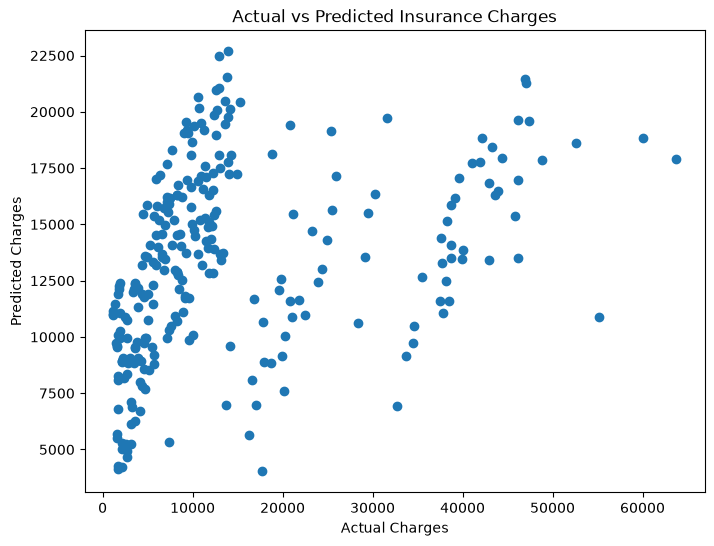

In [73]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

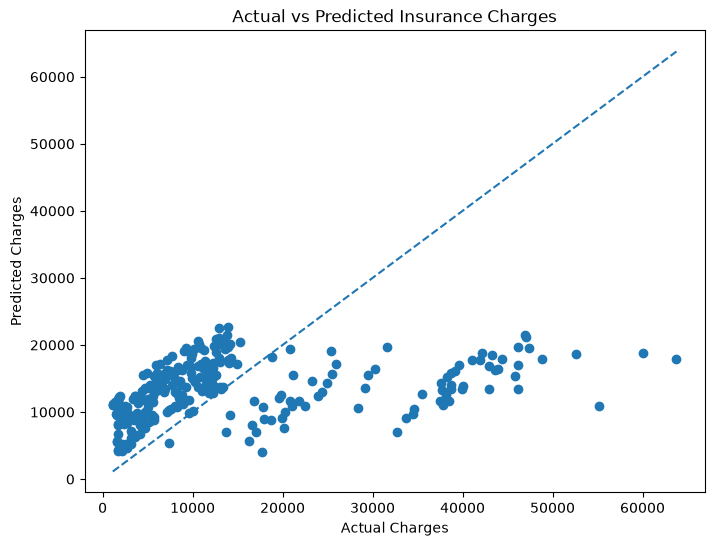

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

In [75]:
import joblib

In [76]:
joblib.dump(model,"Insurance_Linear_Regression.pkl")

['Insurance_Linear_Regression.pkl']

## Key Insights – Day 6

- Built my first Machine Learning model using Linear Regression.
- Used a train-test split to train the model and evaluate it on unseen data.
- Generated predictions for insurance charges using the test data.
- Evaluated the model using MAE, MSE, RMSE, and R² score.
- Compared actual insurance charges with predicted charges using a scatter plot.
- The Actual vs Predicted plot helped identify how close the model's predictions were to the real values.
- Learned how Linear Regression coefficients represent the relationship between input features and the predicted target.
- Saved the trained Linear Regression model for future use.

### Conclusion

This was my first complete Machine Learning workflow, from preparing the data to training, evaluating, visualizing, and saving a model.

# Day 7 – Model Evaluation and Error Analysis

In [78]:
train_pred = model.predict(X_train)

In [79]:
train_r2 = r2_score(y_train, train_pred)

print("Training R²:", train_r2)
print("Testing R² :", r2)

Training R²: 0.1261725430025643
Testing R² : 0.12618040355466686


In [80]:
residual=y_test-y_pred

In [81]:
print(residual.head())

900     -5357.404099
1064    -3485.220114
1256    -5687.689967
298     24680.571174
237    -10998.204574
Name: charges, dtype: float64


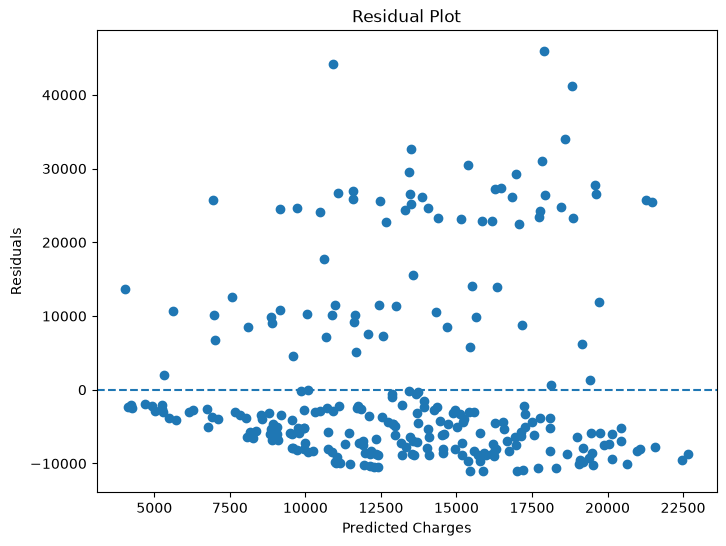

In [84]:

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residual)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Key Insights – Day 7

- Compared the model's performance on training and testing data.
- Learned how to identify possible overfitting and underfitting.
- Calculated residuals using Actual − Predicted.
- Understood positive and negative residuals.
- Created a residual plot to visualize prediction errors.
- Learned that residuals help identify how the model's predictions differ from actual values.

### Conclusion

Day 7 helped me understand that evaluating a Machine Learning model is not only about its R² score. Analyzing prediction errors and residuals provides additional insight into how the model behaves.